In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import linregress

In [2]:
data_clients = pd.read_csv('base_comptoir_espace_table_clients.csv',sep=';')
data_dec_entreprises=pd.read_csv('base_comptoir_espace_table_decisions_entreprises.csv',sep=';')

In [3]:
###Diagrammes circulaires Répartition clientèle 
produit_choisi=1
annee_choisie=1

In [ ]:
df_evenements=pd.DataFrame({'année':np.random.randint(2020,2023,100),'mois':np.random.randint(1,12,100),'jour':np.random.randint(1,30)})
print(df_evenements.head(10))
print('type mois : ',type(df_evenements.mois[0]))
df_evenements['mois_bis']=df_evenements.mois.astype('str')
print('type mois bis : ',type(df_evenements.mois_bis[0]))
df_evenements['mois_bis']=df_evenements['mois_bis'].str.zfill(2)
df_evenements['date']=df_evenements.année.astype(str)+'-'+df_evenements.mois_bis+'-'+df_evenements.jour.astype(str)
print('type date : ',type(df_evenements['date'][0]))
df_evenements['date']=df_evenements['date'].astype('datetime64[ns]')
print(df_evenements['date'].dtype)
print('durée entre deux premières dates : ',df_evenements['date'][1]-df_evenements['date'][0])

           CLI_ID  CLI_ANNEE  CLI_PROD  CLI_PRIX  CLI_CONFORT  CLI_COM  \
CLI_CHOIX                                                                
1            1500       1500      1500      1500         1500     1500   
2             719        719       719       719          719      719   
3            1088       1088      1088      1088         1088     1088   
4            1500       1500      1500      1500         1500     1500   

           CLI_AGE  CLI_GENRE  
CLI_CHOIX                      
1             1500       1500  
2              719        719  
3             1088       1088  
4             1500       1500  


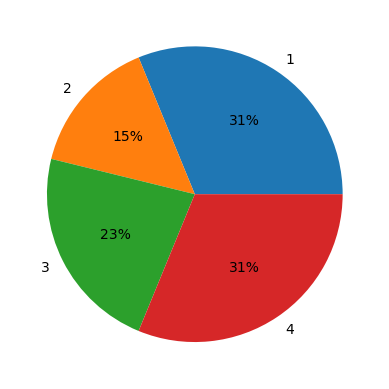

In [74]:
###DIAGRAMMES BARRES CA 2 ANNEES
#Retrouver un tableau donnant les chiffres d'affaires voulus


#Aide pour la réalisation du graphique
'''fig, ax=plt.subplots()
width=0.3
ax.bar(....,-width,align='edge',label='Année 1')
ax.bar(....,width,align='edge',label='Année 2')
ax.set_xticks(....) #Pour changer les étiquettes sur les abscisses
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,p:format(int(x),',').replace(',',' ')))#Pour changer le format des étiquettes sur les ordonnées (pas à savoir faire)'''

numrpoduit = 1
numannee = 1

df_entreprise = data_dec_entreprises.loc[(data_dec_entreprises["ENT_ANNEE"] == numannee) & (data_dec_entreprises["ENT_PROD"] == numrpoduit)]
df_client = data_clients.loc[(data_clients["CLI_ANNEE"]==numannee) & (data_clients["CLI_PROD"]==numrpoduit)& (data_clients["CLI_CHOIX"]!=0)]


df_client=df_client.groupby(by=["CLI_CHOIX"]).count()
print(df_client)
plt.pie(x=df_client["CLI_PROD"], labels=df_client.index, autopct='%1.0f%%')
plt.show()


In [33]:
###HISTOGRAMMES PRIX ATTENDUS POUR UN PRODUIT SUR UNE ANNEE
produit_choisi=1
annee_choisie=1
#Rappel : la fonction plt.hist effectue elle-même le calcul des effectifs à l'intérieur des intervalles qu'on peut spécifier 
#ou qui sont calculés en en donnant le nombre (dans les deux cas on renseigne le paramètres bins). On peut par ailleurs récupérer les effectifs
#via effectifs,_,_=plt.hist(...)

#Aide pour générer ces intervalles : par exemple avec des valeurs qui iraient de 22.3 à 113 et qu'on souhaitait des intervalles d'amplitude 5 de 20 
#à 113 on peut remarquer que 22/5 nous donne le nombre de "cinquaines" à arrondir à l'unité inférieure pour avoir ensuite le premier multiple de cinq directement inférieur
# Les intervalles vont donc de int(22.3/5)*5 à (int(113/5)+1)*5

#Pour mieux comparer les clientèles des différentes entreprises on souhaite avoir la même échelle et les mêmes graduations qu'on déterminera
#Cela peut se faire en utilisant :
#ax.set_yticks(liste des graduations)
#ax.set_ybound(min echelle, max echelle)

In [23]:
###Nuage de points Prix/Confort
produit_choisi=2
annee_choisie=1

#Pour représenter la droite :
res_reg=linregress(... , ...)
a=res_reg.slope
b=res_reg.intercept
coef_cor=res_reg.rvalue
#La droite peut être obtenue en calculant le confort attendu d'après le modèle en fonction du prix attendu (on peut se contenter de le faire
# pour deux points en choisissant les prix extrêmes attendus par la clientèle)

#Pour représenter les points montrant les positionnements des différentes entreprises :
#On peut faire une boucle sur l'ensemble des entreprises concernées par la commercialisation d'un voyage en utilisant une couleur différente pour
#chaque entreprise
'''couleurs = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral','red','green']
plt.plot(... , ... ,color= ... ,marker='o',markersize=12)
plt.text(... , ... ,'Ent'+str( ... ))'''

TypeError: len() of unsized object